在ModelArts中运行：https://pangu.huaweicloud.com/gallery/asset-detail.html?id=4cc9d5f6-d818-434a-a297-5f36e7ba2c9f

fine-tune `LayoutLMv2ForTokenClassification` on the [CORD](https://github.com/clovaai/cord) dataset.  该模型的目标是对扫描文档（即收据）中出现的单词进行适当的标记。
这项任务被视为一个命名实体识别（NER）问题（序列标注）。与BERT相比，LayoutLMv2在将标记编码成向量时，还额外整合了<b>视觉和布局信息</b>。这使得LayoutLMv2模型在文档理解任务上非常强大。

LayoutLMv1是LayoutLM的升级版。LayoutLMv1的主要创新之处在于它还预训练了视觉嵌入，而原始的LayoutLM只在微调阶段添加视觉嵌入。


* 论文: https://arxiv.org/pdf/2012.14740
* Github仓: https://github.com/microsoft/unilm/tree/master/layoutlmv2


In [ ]:
import os

# 设置环境变量
os.environ['CUDA_HOME'] = '/home'

In [ ]:
import warnings

# 忽略所有警告
warnings.filterwarnings('ignore')

In [ ]:
import mindspore

mindspore.context.get_context('device_target')

## CORD数据集准备

In [ ]:
from mindnlp.dataset import load_dataset

In [ ]:
ds = load_dataset('naver-clova-ix/cord-v2')

In [ ]:
ds

In [ ]:
train_dataset = ds['train']
train_dataset.get_col_names(), train_dataset.get_dataset_size()

In [ ]:
data = next(train_dataset.create_dict_iterator(output_numpy=True))
data.keys()

先看一张数据集的图像

In [ ]:
from PIL import Image
import io

def show_image_from_arr(img_array, resize=None):
    image = Image.fromarray(img_array, 'RGB')
    
    if resize is not None:  # 调整图片大小
        image = image.resize((resize, resize))
    # 显示图片
    image.show()
    
    return image

image = show_image_from_arr(data['image'])

读取相应的OCR注释

In [ ]:
annotations = data['ground_truth']
type(annotations), annotations.dtype

In [ ]:
data_js = eval(str(annotations))
data_js.keys()

In [ ]:
# This particular example has 71 OCR annotations，最初的版本不止71，因为删除了一些包含个人信息的数据，如顾客个人信息、支付信息等

len(data_js['valid_line'])

In [ ]:
"""ArithmeticError
注意到上述票据图像的大部分有效行，每行的第一个”单词“其实是菜单的菜品数量，所以data_js['valid_line'][0]的category为menu.cnt （联想记忆：menu count）
另外，被识别为文本 "x"的 text 是 起一个分割作用的标记，本次实验将在后续进行忽略

"""
data_js['valid_line'][0]

In [ ]:
# menu.nm 表示菜品名称
data_js['valid_line'][1]['words'][0], data_js['valid_line'][1]['category']

In [ ]:
# 票据的元数据信息：数据集版本、数据集是训练/验证/测试集、票据图像ID，票据图像的尺寸
data_js['meta']

In [ ]:
data_js['roi']

In [ ]:
data_js['repeating_symbol']

让我们用相应的边界框对图像进行注释：使用text的边框坐标点信息，绘制出相应的文本框，然后给出对应文本框中的文本标签

In [ ]:
import random

labels = ['menu.cnt',
 'menu.discountprice',
 'menu.etc',
 'menu.itemsubtotal',
 'menu.nm',
 'menu.num',
 'menu.price',
 'menu.sub_cnt',
 'menu.sub_etc',
 'menu.sub_nm',
 'menu.sub_price',
 'menu.sub_unitprice',
 'menu.unitprice',
 'menu.vatyn',
 'sub_total.discount_price',
 'sub_total.etc',
 'sub_total.othersvc_price',
 'sub_total.service_price',
 'sub_total.subtotal_price',
 'sub_total.tax_price',
 'total.cashprice',
 'total.changeprice',
 'total.creditcardprice',
 'total.emoneyprice',
 'total.menuqty_cnt',
 'total.menutype_cnt',
 'total.total_etc',
 'total.total_price',
 'void_menu.nm',
 'void_menu.price']

get_colors = lambda n: list(map(lambda i: "#" + "%06x" % random.randint(0, 0xFFFFFF),range(n)))
colors = get_colors(len(labels))
print(colors)

In [ ]:
from PIL import ImageDraw, ImageFont

draw = ImageDraw.Draw(image, "RGBA")   

font = ImageFont.load_default()

# 一个字典label2color，用于将标签（label）映射到对应的颜色（colors）
label2color = {label: colors[idx] for idx, label in enumerate(labels)}

for annotation in data_js['valid_line']:  # 遍历数据中的有效线（valid_line）部分，对于每个注释（annotation）
    # 提取标签（label）和文本（words）
    label = annotation['category']
    words = annotation['words']

    # 对于每个文本（word），提取坐标（quad）并将其转换为矩形框（box）
    for word in words:
        coordinates = word['quad']
        x1, y1 = coordinates['x1'], coordinates['y1']
        x3, y3 = coordinates['x3'], coordinates['y3']
        box = [x1, y1, x3, y3]

        # 使用draw.rectangle()方法在图片上绘制矩形框，并使用draw.text()方法在矩形框内部绘制标签文本
        draw.rectangle(box, outline=label2color[label], width=2)
        draw.text((box[0]+10, box[1]+5), label, fill=label2color[label], font=font)

image

## 处理并获取需要的图像信息、OCR注释信息

In [ ]:
from tqdm import tqdm
from PIL import Image

def normalize_bbox(bbox, width, height):
     return [
         int(1000 * (bbox[0] / width)),
         int(1000 * (bbox[1] / height)),
         int(1000 * (bbox[2] / width)),
         int(1000 * (bbox[3] / height)),
     ]

def generate_annotations(dataset, text_ignore: list = ['x']):
    words = []
    boxes = []
    labels = []
    images = []

    for data in tqdm(dataset.create_dict_iterator(output_numpy=True)):
        js = eval(str(data['ground_truth']))

        words_example = []
        boxes_example = []
        labels_example = []

        width, height = js['meta']['image_size']['width'], js['meta']['image_size']['height']
        # loop over OCR annotations
        for elem in js['valid_line']:
            for word in elem['words']:
                # get word
                txt = word['text']

                # get bounding box
                # important: each bounding box should be in (upper left, lower right) format
                # it took me some time to understand the upper left is (x1, y3)
                # and the lower right is (x3, y1)
                x1 = word['quad']['x1']
                y1 = word['quad']['y1']
                x3 = word['quad']['x3']
                y3 = word['quad']['y3']

                box = [x1, y1, x3, y3]
                box = normalize_bbox(box, width=width, height=height)

                # ADDED
                # skip empty word
                if len(txt) < 1: 
                    continue
                if min(box) < 0 or max(box) > 1000: # another bug in which a box had -4
                    continue
                if ((box[3] - box[1]) < 0) or ((box[2] - box[0]) < 0): # another bug in which a box difference was -12
                    continue
                if txt in text_ignore:
                    continue
                # ADDED

                words_example.append(txt)
                boxes_example.append(box) 
                labels_example.append(elem['category'])
      
        words.append(words_example) 
        boxes.append(boxes_example)
        labels.append(labels_example)
        image = Image.fromarray(data['image'], 'RGB')
        images.append(image)
  
    return words, boxes, labels, images

In [ ]:
val_dataset = ds['validation']
test_dataset = ds['test']

In [ ]:
words_train, boxes_train, labels_train, images_train = generate_annotations(train_dataset)
words_val, boxes_val, labels_val, images_val = generate_annotations(val_dataset)
words_test, boxes_test, labels_test, images_test = generate_annotations(test_dataset)

In [ ]:
train_dataset.get_dataset_size(), len(labels_train), len(words_train), len(boxes_train), len(images_train)

In [ ]:
len(labels_train[0]), len(words_train[0]), len(boxes_train[0])

In [ ]:
labels_train[0]

In [ ]:
words_train[0]

In [ ]:
boxes_train[0]

再来看一个和参考代码仓：https://github.com/NielsRogge/Transformers-Tutorials 的LayoutLMv2\CORD的给出的一个示例

In [ ]:
boxes_train[580]

In [ ]:
for i in range(len(words_train)):
    for w in words_train[i]:
        if w == 'Tebu':
            print(i)
            break

In [ ]:
images_train[580]

In [ ]:
labels_train[580]

In [ ]:
words_train[580]

## 保存处理好的数据

In [ ]:
import pickle

train_path = './data/cord_train.pkl'
with open(train_path, 'wb') as f:
    pickle.dump([words_train, labels_train, boxes_train, images_train], f)

val_path = './data/cord_val.pkl'
with open(val_path, 'wb') as f:
    pickle.dump([words_val, labels_val, boxes_val, images_val], f)

test_path = './data/cord_test.pkl'
with open(test_path, 'wb') as f:
    pickle.dump([words_test, labels_test, boxes_test, images_test], f)

## 准备模型的输入数据——MiondSpore数据集迭代器


In [ ]:
import pandas as pd
train_path = './data/cord_train.pkl'
val_path = './data/cord_val.pkl'
test_path = './data/cord_test.pkl'

train = pd.read_pickle(train_path)
val = pd.read_pickle(val_path)
test = pd.read_pickle(test_path)

In [ ]:
# 需要定义一个包含所有唯一标签的列表。首先，让我们计算每个标签出现的次数：

from collections import Counter

all_labels = [item for sublist in train[1] for item in sublist] + [item for sublist in val[1] for item in sublist] + [item for sublist in test[1] for item in sublist]
label2count = Counter(all_labels)
label2count

如上所见，有些标签包含的例子非常少。让我们用“中立”标签“O”（代表“Outside”）来替换它们。

In [ ]:
count_min = 20

replacing_labels = dict()

for label, count in label2count.items():
    if count < count_min:
        replacing_labels[label] = 'O'

replacing_labels

In [ ]:
def replace_elem(elem):
    try:
        return replacing_labels[elem]
    except KeyError:
        return elem
    
def replace_list(ls):
    return [replace_elem(elem) for elem in ls]

train[1] = [replace_list(ls) for ls in train[1]]
val[1] = [replace_list(ls) for ls in val[1]]
test[1] = [replace_list(ls) for ls in test[1]]

In [ ]:
# 计算经过替换操作后的每个标签出现的次数：

from collections import Counter

all_labels = [item for sublist in train[1] for item in sublist] + [item for sublist in val[1] for item in sublist] + [item for sublist in test[1] for item in sublist]
label2count = Counter(all_labels)
label2count

In [ ]:
labels = list(label2count.keys())
print(labels)

In [ ]:
label2id = {label: idx for idx, label in enumerate(labels)}
id2label = {idx: label for idx, label in enumerate(labels)}
print(label2id)
print(id2label)

In [ ]:
import json

"""保存上述两个字典，后续进行模型推理结果的解析可用
json.dump()函数可用于将Python的字典对象转换为JSON格式并写入文件。
 ensure_ascii=False参数确保非ASCII字符被正确处理，indent=4参数用于美化输出，使JSON文件易于阅读
"""

# 将字典保存为JSON文件
with open('./LayoutLMv2_For_TokenClassificaion/label2id.json', 'w', encoding='utf-8') as f:
    json.dump(label2id, f, ensure_ascii=False, indent=4)
    
with open('./LayoutLMv2_For_TokenClassificaion/id2label.json', 'w', encoding='utf-8') as f:
    json.dump(id2label, f, ensure_ascii=False, indent=4)

In [ ]:
class CORDDataset:
    """CORD dataset."""

    def __init__(self, annotations, images, processor=None, max_length=512):
        """
        Args:
            annotations (List[List]): List of lists containing the word-level annotations (words, labels, boxes).
            images (List[List]): List of  all the document images.
            processor (LayoutLMv2Processor): Processor to prepare the text + image.
        """
        self.words, self.labels, self.boxes = annotations
        self.images = images
        self.processor = processor

        self.max_length = max_length
        
        self.encoded_inputs_list = []
        self.__get_encoded_inputs_list__()
    
    def __get_encoded_inputs_list__(self):
        for idx in range(self.__len__()):
            # first, take an image
            image = self.images[idx]

            # get word-level annotations 
            words = self.words[idx]
            boxes = self.boxes[idx]
            word_labels = self.labels[idx]

            assert len(words) == len(boxes) == len(word_labels)

            word_labels = [label2id[label] for label in word_labels]
            # use processor to prepare everything
            encoded_inputs = self.processor(image, words, boxes=boxes, word_labels=word_labels, 
                                            padding='max_length', truncation=True, 
                                            return_tensors="np", max_length=self.max_length)

            # remove batch dimension
            for k,v in encoded_inputs.items():
                encoded_inputs[k] = v.squeeze()

            # 注意这里和 pytorch 的写法不同，是为了后续使用mindspore的dataset进行shuffle 和 batch操作
            # 在 pytorch中，这两个操作需要另外的Dataloader类，而在mindspore中，这两个操作可以直接在 dataset 对象上进行，所以这里直接返回一个 tuple
            self.encoded_inputs_list.append( tuple(encoded_inputs.values()) )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.encoded_inputs_list[idx]

In [ ]:
from mindnlp.transformers import LayoutLMv2Processor

model_name = "microsoft/layoutlmv2-base-uncased"
processor = LayoutLMv2Processor.from_pretrained(model_name, apply_ocr=False)
processor

In [ ]:
train_dataset = CORDDataset(annotations=train[:-1],
                            images=train[-1], 
                            processor=processor)
val_dataset = CORDDataset(annotations=val[:-1],
                            images=val[-1], 
                            processor=processor)
test_dataset = CORDDataset(annotations=test[:-1],
                            images=test[-1], 
                            processor=processor)

注意对齐原代码仓的脚本逻辑要求的各个输入数据的形状：<br>
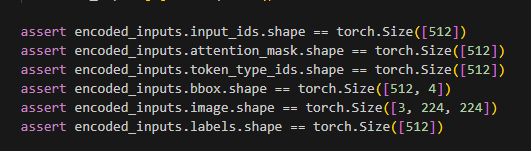


In [ ]:
encoded_inputs = train_dataset[0]

In [ ]:
col_names = ['input_ids', 'token_type_ids', 'attention_mask', 'bbox', 'labels', 'image']

for k,v in zip(col_names, encoded_inputs):
    print(k, v.shape, v.dtype)

In [ ]:
print(processor.tokenizer.decode(encoded_inputs[0]))

In [ ]:
train[0][580]

In [ ]:
train[1][580]

下一步，创建数据迭代器

In [ ]:
from mindspore.dataset import GeneratorDataset

col_names = ['input_ids', 'token_type_ids', 'attention_mask', 'bbox', 'labels', 'image']

train_dataloader = GeneratorDataset(train_dataset, shuffle=True, column_names=col_names)
val_dataloader = GeneratorDataset(val_dataset, shuffle=True, column_names=col_names)
test_dataloader = GeneratorDataset(test_dataset, column_names=col_names)

In [ ]:
# 所有数据集进行要分批

batch_size = 2
train_dataloader = train_dataloader.batch(batch_size)
val_dataloader = val_dataloader.batch(batch_size)
test_dataloader = test_dataloader.batch(batch_size)

In [ ]:
train_dataloader.get_col_names()

In [ ]:
dict_iterator0 = train_dataloader.create_dict_iterator()

In [ ]:
datas = next(dict_iterator0)
for k,v in datas.items():
    print(k, v.shape, v.dtype)

## Train the model

In [ ]:
from mindnlp.transformers import LayoutLMv2ForTokenClassification

num_labels = len(label2count.keys())
model = LayoutLMv2ForTokenClassification.from_pretrained(model_name, num_labels=num_labels)

In [ ]:
model

In [ ]:
from mindnlp.core.optim import AdamW
optimizer = AdamW(model.trainable_params(), lr =5e-5)

global_step = 0
num_train_epochs = 4

In [ ]:
from mindnlp.core.autograd import value_and_grad

def forward_fn(batch):
    # get the inputs;
    input_ids = batch['input_ids']
    bbox = batch['bbox']
    image = batch['image']
    attention_mask = batch['attention_mask']
    token_type_ids = batch['token_type_ids']
    labels = batch['labels']

    outputs = model(input_ids=input_ids,
                    bbox=bbox,
                    image=image,
                    attention_mask=attention_mask,
                    token_type_ids=token_type_ids,
                    labels=labels) 
    loss = outputs.loss
    
    return loss

grad_fn = value_and_grad(forward_fn, model.trainable_params(), attach_grads=True)

In [ ]:
from tqdm import tqdm

# put the model in training mode
model.set_train(True)

for epoch in range(num_train_epochs):  
    print("Epoch:", epoch)
    for batch in tqdm(train_dataloader.create_dict_iterator()):
        optimizer.zero_grad()
        # forward, backward + optimize
        loss = grad_fn(batch)
        optimizer.step()


        # print loss every 100 steps
        if global_step % 100 == 0:
            print(f"Loss after {global_step} steps: {loss.item()}")

        global_step += 1

In [ ]:
model.save_pretrained("./LayoutLMv2_For_TokenClassificaion/Checkpoints202411")

In [ ]:
processor.save_pretrained('./LayoutLMv2_For_TokenClassificaion/processorPretrained')

## Evaluation

Let's evaluate the model on the test set. First, let's do a sanity check on the first example of the test set.

In [ ]:
pretrained_model_path = "./LayoutLMv2_For_TokenClassificaion/Checkpoints202411"
model = LayoutLMv2ForTokenClassification.from_pretrained(pretrained_model_path)

In [ ]:
encoding = next(test_dataloader.create_dict_iterator())
processor.tokenizer.decode(encoding['input_ids'][0])  # tokenizer.decode方法可以将token的数字索引解析为实际token原文本

In [ ]:
# 取出上述token对应的标签（除了开始/结束标记以及填充标记[PAD]等特殊标记代表的token）
ground_truth_labels = [id2label[label] for label in encoding['labels'][0].squeeze().tolist() if label != -100]
print(ground_truth_labels)

In [ ]:
model.set_train(False)
# forward pass
outputs = model(input_ids=encoding['input_ids'], attention_mask=encoding['attention_mask'],
                token_type_ids=encoding['token_type_ids'], bbox=encoding['bbox'],
                image=encoding['image'])

print(type(outputs))
print(outputs.keys())

In [ ]:
# 打印模型预测的标签，和上述一样，只打印一个批次中的第一个样本
prediction_indices = outputs.logits.argmax(-1).squeeze().tolist()
print(prediction_indices[0])

In [ ]:
# 将预测的数字标签转为具有真实含义的文本标签
# 我们只看本身不是开始、结束、填充等特殊标记位置的标签
predictions = [id2label[label] for gt, label in zip(encoding['labels'][0].squeeze().tolist(), prediction_indices[0]) if gt != -100]
print(predictions)

对整个测试集进行评估

In [ ]:
import numpy as np
from tqdm import tqdm

preds_val = None
out_label_ids = None

# put model in evaluation mode
model.set_train(False)
for batch in tqdm(test_dataloader.create_dict_iterator(), desc="Evaluating"):
    input_ids = batch['input_ids']
    bbox = batch['bbox']
    image = batch['image']
    attention_mask = batch['attention_mask']
    token_type_ids = batch['token_type_ids']
    labels = batch['labels']

    # forward pass
    outputs = model(input_ids=input_ids, bbox=bbox, image=image, attention_mask=attention_mask, 
                    token_type_ids=token_type_ids, labels=labels)

    if preds_val is None:
        preds_val = outputs.logits.asnumpy()
        out_label_ids = batch["labels"].asnumpy()
    else:
        preds_val = np.append(preds_val, outputs.logits.asnumpy(), axis=0)
        out_label_ids = np.append(out_label_ids, batch["labels"].asnumpy(), axis=0)

使用seqeval模块进行评估<br>
Seqeval是一个用于序列标注评估的Python框架，它能够评估如命名实体识别（NER）、词性标注（POS tagging）、语义角色标注（SRL）等分块任务的性能.

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from seqeval.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score)

def results_test(preds, out_label_ids, labels):
    preds = np.argmax(preds, axis=2)

    label_map = {i: label for i, label in enumerate(labels)}

    out_label_list = [[] for _ in range(out_label_ids.shape[0])]
    preds_list = [[] for _ in range(out_label_ids.shape[0])]

    for i in range(out_label_ids.shape[0]):
        for j in range(out_label_ids.shape[1]):
            if out_label_ids[i, j] != -100:
                out_label_list[i].append(label_map[out_label_ids[i][j]])
                preds_list[i].append(label_map[preds[i][j]])

    results = {
        "precision": precision_score(out_label_list, preds_list),
        "recall": recall_score(out_label_list, preds_list),
        "f1": f1_score(out_label_list, preds_list),
    }
    return results, classification_report(out_label_list, preds_list)

In [ ]:
labels = list(set(all_labels))
val_result, class_report = results_test(preds_val, out_label_ids, labels)
print("Overall results:", val_result)
print(class_report)

## Inference(模型推理的流程化和结果可视化)

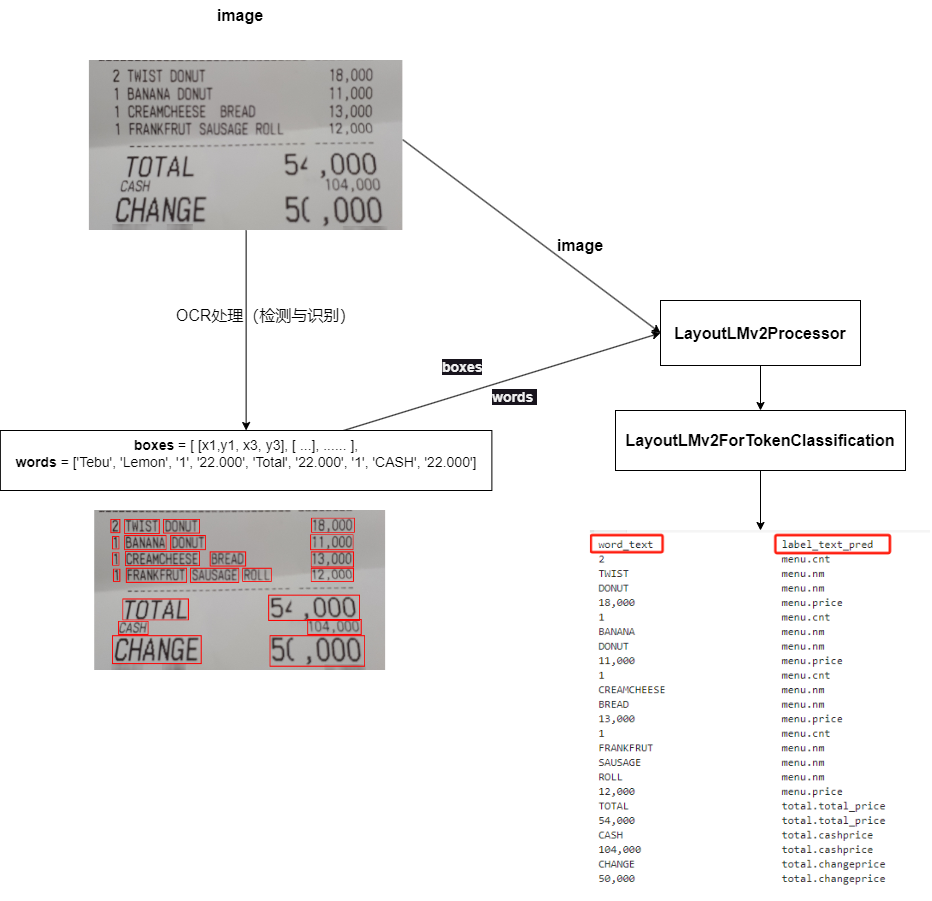

In [ ]:
from mindnlp.transformers import LayoutLMv2Processor, LayoutLMv2ForTokenClassification

# # 如果本地机器安装了Tesseract-OCR引擎 和 pytesseract库，可以设置 apply_ocr设置为True，
processor_infer = LayoutLMv2Processor.from_pretrained("./LayoutLMv2_For_TokenClassificaion/processorPretrained", apply_ocr=False)  

pretrained_model_path = "./LayoutLMv2_For_TokenClassificaion/Checkpoints202411"
model_infer = LayoutLMv2ForTokenClassification.from_pretrained(pretrained_model_path)

In [ ]:
import json

class IntKeysJSONDecoder(json.JSONDecoder):
    def __init__(self, *args, **kwargs):
        # 想要确保键是整数，可以设置object_pairs_hook
        kwargs['object_pairs_hook'] = lambda pairs: dict((int(k), v) for k, v in pairs)
        super().__init__(*args, **kwargs)

# 加载JSON文件
with open('./LayoutLMv2_For_TokenClassificaion/id2label.json', 'r', encoding='utf-8') as f:
    id2label = json.load(f, cls=IntKeysJSONDecoder)
    
"""数字索引到英文文本标注的映射"""
print(id2label)

In [ ]:
from mindspore import Tensor

def inference(image, words, boxes):
    """
    参数：
        image: 图像对象
        words：一个列表，待进行序列标注的文本token
        boxes: words列表的每个token在图像image的“检测框”的位置信息
    return：一个列表word_labels，元素对应 words的每个token的标注标签
    """
    # 若加载 processor 时 apply_ocr=True，此时只需传输 图像数据即可，processor内部会对输入图像image进行OCR识别
    encoded_inputs = processor_infer(image, words, boxes=boxes,    # boxes 和 words应该分别是 OCR 的检测阶段和文本识别阶段得到的结果 
                                 word_labels = [-1] * len(words),  # 因为实际的token标签还未知（待模型预测出来），所以这里统一用 -1 代替
                                 padding='max_length', truncation=True, return_tensors="np")  # 这里不能直接通过设置return_tensors='ms'输出Tensor
    
    input_ids = Tensor(encoded_inputs['input_ids'])
    attention_mask = Tensor(encoded_inputs['attention_mask'])
    token_type_ids = Tensor(encoded_inputs['token_type_ids'])
    bbox = Tensor(encoded_inputs['bbox'])
    image = Tensor(encoded_inputs['image'])
    
    model_infer.set_train(False)
    # forward pass
    outputs = model_infer(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, bbox=bbox, image=image)
    
    # 模型预测的标签的id
    prediction_indices = outputs.logits.argmax(-1).squeeze().tolist()
    
    # 模型对 每个 token （包含特殊标记作用的token）的id 都预测出了对应的标签id，注意后续取出实际预测的token标签时跳过特殊token（开始、结束、填充等标记）的标签
    labels = encoded_inputs['labels'].squeeze().tolist()
    label_special = labels[0]  # 特殊标记的标签，一般为-100
    
    # 获取预测的 words每个 token元素对应的文本标注
    prediction_labels = [id2label[label_pred_id] for gt, label_pred_id in zip(labels, prediction_indices) if gt != label_special]
    
    return prediction_labels

In [ ]:
"""加载测试数据"""
import pandas as pd


imgs_path = './LayoutLMv2_Apps/data_tested/images.pkl'
annotations_path = './LayoutLMv2_Apps/data_tested/boxes2words.pkl'
labels_path = './LayoutLMv2_Apps/data_tested/labels.pkl'

images_tested = pd.read_pickle(imgs_path)
annotations_tested = pd.read_pickle(annotations_path)
labels_tested = pd.read_pickle(labels_path)

words_tested, boxes_tested = annotations_tested[0], annotations_tested[1]

In [ ]:
from PIL import ImageDraw, ImageFont, Image
import numpy as np

def draw_rectangle(image, boxes: list = []):
    """
    绘制图像image的文本矩阵框，boxes 的 每个元素为[x1,y1,x3,y3]
    return 绘制了文本框的图像
    """
    # 深度拷贝
    copied_image_array = np.array(image)
    copied_image_deep = Image.fromarray(copied_image_array)
    draw = ImageDraw.Draw(copied_image_deep, "RGBA")   

    font = ImageFont.load_default()

    for box in boxes:
        # 使用draw.rectangle()方法在图片上绘制矩形框
        draw.rectangle(box, outline='#FF0000', width=2)
    
    return copied_image_deep


"""这里假设有OCR处理，不是实际的OCR处理，模拟操作，得到图像的检测框的坐标以及框内识别得到的文本"""
def get_OCR_result_simulate(image_id):
    image = images_tested[image_id]
    boxes = boxes_tested[image_id]
    words = words_tested[image_id]
    
    
    img_with_rectangles = draw_rectangle(image, boxes)  # 带文本框的图像
    
    width, height = image.size
    # 矩阵狂归一化操作，和模型训练前准备处理数据时一致
    def normalize_bbox(bbox):
         return [
             int(1000 * (bbox[0] / width)),
             int(1000 * (bbox[1] / height)),
             int(1000 * (bbox[2] / width)),
             int(1000 * (bbox[3] / height)),
         ]
    for i in range(len(words)):
        boxes[i] = normalize_bbox(boxes[i])
    
    return boxes, words, image, img_with_rectangles

In [ ]:
"""尝试推理测试集的一个样本"""
i = np.random.randint(0,len(words_tested))

boxes, words, image, img_with_rectangles = get_OCR_result_simulate(i)

In [ ]:
labels_real = labels_tested[i]

labels_pred = inference(image, words, boxes)

In [ ]:
fill_str = ' ' * 30
print(f"{('  label_real'+fill_str)[:30]}{('  label_pred'+fill_str)[:30]}")

for real, pred in zip(labels_real, labels_pred):
    sign = '√' if real == pred else 'X'
    info = f"{(real+fill_str)[:30]}{(pred+fill_str)[:30]} √ {sign}"
    print(info)

In [ ]:
image.show()

In [ ]:
img_with_rectangles.show()

In [ ]:
fill_str = ' ' * 30
print(f"{('word_text'+fill_str)[:30]}{('label_text_pred'+fill_str)[:30]}")

for word, pred_label in zip(words, labels_pred):
    info = f"{(word+fill_str)[:30]}{pred_label+fill_str}"
    print(info)